<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/ADI_PM25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
from numba import njit

# ======================================================
# 1. LOAD GRID + MODEL FIELD
# ======================================================
ds = xr.open_dataset("EMEP_yearly_2015.nc")

lon = ds["lon"].values
lat = ds["lat"].values

model_field = ds["SURF_ug_PM25_rh50"].values
if model_field.ndim == 3:
    model_field = model_field[0]

Ny, Nx = model_field.shape
ds.close()

# ======================================================
# 2. LOAD GRIDCELL DATA
# ======================================================
df = pd.read_csv("basePM25_gridcell_average.csv")

grid_lon = df["nearest_grid_lon"].values
grid_lat = df["nearest_grid_lat"].values

obs = df["SURF_ug_PM25_rh50"].values
model_vals = df["nearest_SURF_ug_PM25_rh50"].values

bias_values = obs - model_vals

# ======================================================
# 3. MAP TO GRID
# ======================================================
def find_idx(lo, la):
    i = np.argmin(np.abs(lon - lo))
    j = np.argmin(np.abs(lat - la))
    return j, i

points = np.array([find_idx(grid_lon[i], grid_lat[i]) for i in range(len(bias_values))])

# ======================================================
# 4. DIFFUSION COEFFICIENT (FIXED)
# ======================================================
k_base = 1.0 / (1.0 + 0.1 * model_field)   # smoother scaling
k_base = k_base / np.max(k_base)

# ======================================================
# 5. VELOCITY FIELD (CFL SAFE)
# ======================================================
dx = np.mean(np.diff(lon))
dy = np.mean(np.diff(lat))

dCdx = np.gradient(model_field, dx, axis=1)
dCdy = np.gradient(model_field, dy, axis=0)

ux = -dCdx
uy = -dCdy

mag = np.sqrt(ux**2 + uy**2) + 1e-8
ux /= mag
uy /= mag

# CFL-safe scaling
cfl = 0.4
ux *= cfl * dx
uy *= cfl * dy

# ensure contiguous (Numba)
k_base = np.ascontiguousarray(k_base)
ux = np.ascontiguousarray(ux)
uy = np.ascontiguousarray(uy)

# ======================================================
# 6. SOLVER
# ======================================================
@njit
def solve_hybrid(points, values, k, ux, uy, Ny, Nx, adv_coeff):

    bias = np.zeros((Ny, Nx))
    mask = np.zeros((Ny, Nx), dtype=np.uint8)

    for p in range(points.shape[0]):
        j = points[p, 0]
        i = points[p, 1]
        bias[j, i] = values[p]
        mask[j, i] = 1

    max_iter = 3000
    tol = 1e-4
    omega = 1.2

    for it in range(max_iter):

        max_diff = 0.0

        for j in range(1, Ny - 1):
            for i in range(1, Nx - 1):

                if mask[j, i] == 1:
                    continue

                old_val = bias[j, i]

                # ---- Diffusion ----
                k_e = 0.5 * (k[j, i] + k[j, i+1])
                k_w = 0.5 * (k[j, i] + k[j, i-1])
                k_n = 0.5 * (k[j, i] + k[j+1, i])
                k_s = 0.5 * (k[j, i] + k[j-1, i])

                numerator = (
                    k_e * bias[j, i+1] +
                    k_w * bias[j, i-1] +
                    k_n * bias[j+1, i] +
                    k_s * bias[j-1, i]
                )

                denom = k_e + k_w + k_n + k_s + 1e-12
                diffusion = numerator / denom

                # ---- Advection (FIXED: no extra scaling) ----
                adv = 0.0

                if ux[j, i] > 0:
                    adv += ux[j, i] * (bias[j, i] - bias[j, i-1])
                else:
                    adv += ux[j, i] * (bias[j, i+1] - bias[j, i])

                if uy[j, i] > 0:
                    adv += uy[j, i] * (bias[j, i] - bias[j-1, i])
                else:
                    adv += uy[j, i] * (bias[j+1, i] - bias[j, i])

                new_val = (1 - omega) * old_val + omega * (diffusion - adv_coeff * adv)

                if abs(new_val) > 1e6:
                    return bias

                bias[j, i] = new_val

                diff = abs(new_val - old_val)
                if diff > max_diff:
                    max_diff = diff

        # ---- Boundary (FIXED: Neumann) ----
        bias[0, :] = bias[1, :]
        bias[-1, :] = bias[-2, :]
        bias[:, 0] = bias[:, 1]
        bias[:, -1] = bias[:, -2]

        if max_diff < tol:
            break

    return bias

# ======================================================
# 7. TRAIN / VALIDATION SPLIT
# ======================================================
np.random.seed(42)

idx = np.arange(len(points))
np.random.shuffle(idx)

split = int(0.8 * len(points))

train_points = points[idx[:split]]
train_values = bias_values[idx[:split]]

val_points = points[idx[split:]]
val_values = bias_values[idx[split:]]

# ======================================================
# 8. HYPERPARAMETER SEARCH (FASTER)
# ======================================================
adv_grid = np.linspace(0.0, 0.2, 10)
k_power_grid = [0.5, 0.7, 1.0, 1.3]

best_rmse = 1e9

for p in k_power_grid:

    k_mod = k_base ** p

    for adv in adv_grid:

        bias_field = solve_hybrid(train_points, train_values, k_mod, ux, uy, Ny, Nx, adv)

        # VECTORISED RMSE (FIXED)
        j_idx = val_points[:, 0]
        i_idx = val_points[:, 1]

        diff = bias_field[j_idx, i_idx] - val_values
        rmse = np.sqrt(np.mean(diff**2))

        if np.isnan(rmse) or np.isinf(rmse):
            continue

        print("p:", p, "adv:", adv, "RMSE:", rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_adv = adv
            best_p = p

print("\nBEST RESULTS")
print("Best adv_coeff:", best_adv)
print("Best k power:", best_p)
print("Best RMSE:", best_rmse)

# ======================================================
# 9. FINAL RUN
# ======================================================
k_final = k_base ** best_p
final_bias = solve_hybrid(points, bias_values, k_final, ux, uy, Ny, Nx, best_adv)

# ======================================================
# 10. SAVE OUTPUT
# ======================================================
ds_out = xr.Dataset(
    {"Interpolated_Bias": (["lat", "lon"], final_bias)},
    coords={"lon": lon, "lat": lat},
)

ds_out.to_netcdf("Bias_Hybrid_Optimized_PM25.nc")

print("\nSaved: Bias_Hybrid_Optimized_PM25.nc")

BEST RESULTS
Best adv_coeff: 0.2
Best k power: 1.0
Best RMSE: 3.4989557261534565

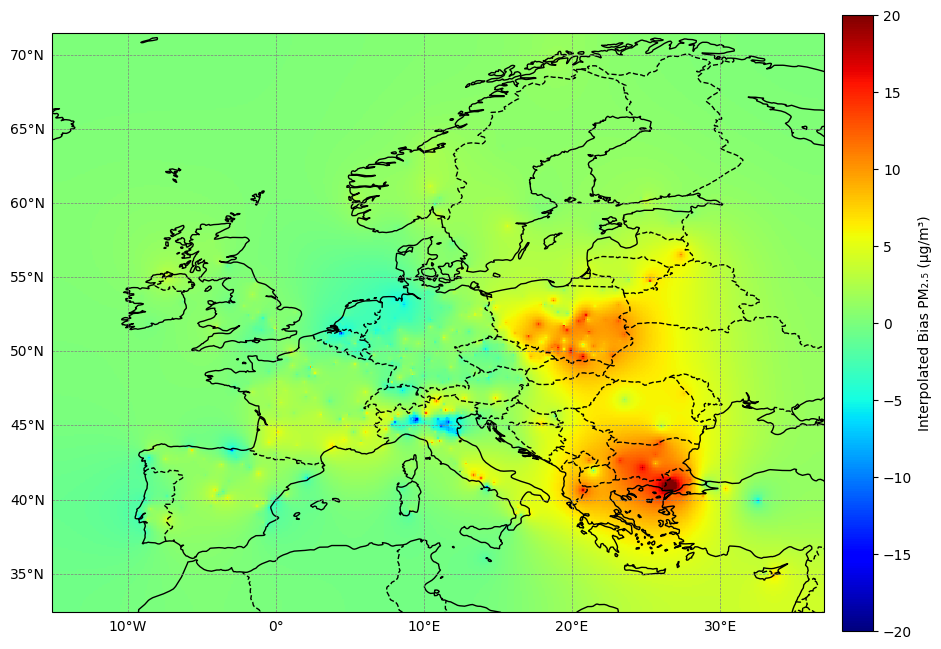

In [4]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias NetCDF File ===
bias_netcdf_path = "Bias_Hybrid_Optimized_PM25.nc"  # File already saved
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias (residuals)
interpolated_bias = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -20  # Minimum bias value for color scale
cbar_max = 20  # Maximum bias value for color scale

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias
im = ax.pcolormesh(lon, lat, interpolated_bias, transform=ccrs.PlateCarree(), cmap="jet", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias PM₂.₅ (µg/m³)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

In [10]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_nc_path = "Bias_Hybrid_Optimized_PM25.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_ADI_ADD.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias
    interpolated_bias = bias_nc.variables["Interpolated_Bias"][:]

    # === Compute the Unbiased PM₂.₅ ===
    pm25_corrected = pm25_original + interpolated_bias  # Apply the bias correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Bias correction completed successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)

 Bias correction completed successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_ADI_ADD.nc


In [11]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_ADI_ADD.nc"  # Your original file
output_file = "BaseCase_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

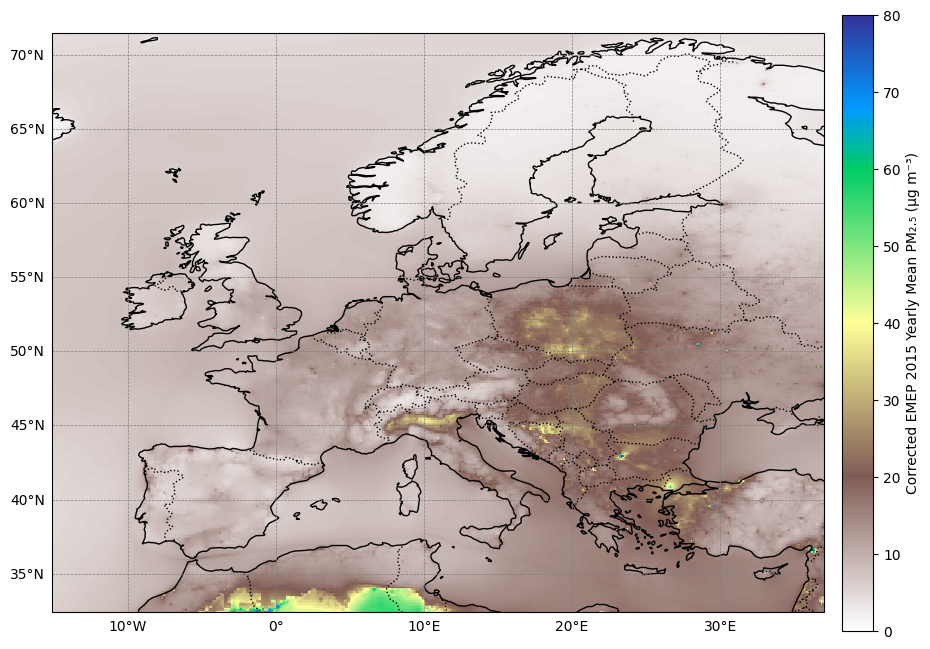

In [12]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2015 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()


In [13]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2022.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "Bias_Hybrid_Optimized_PM25.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected_PM25_Y_ADI_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)



Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected_PM25_Y_ADI_ADD.nc


In [14]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected_PM25_Y_ADI_ADD.nc"  # Your original file
output_file = "Scen_2022_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2022.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")


 Correction completed! Renamed and fixed NetCDF saved as: Scen_2022_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

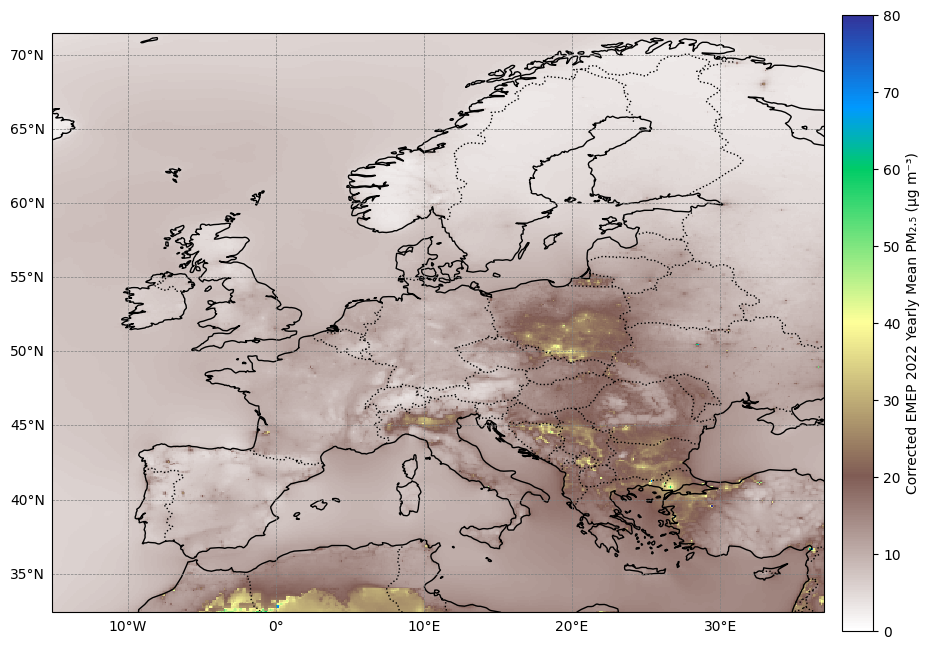

In [15]:


import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2022_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2022 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [40]:
import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2023.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "Bias_Hybrid_Optimized_PM25.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected3_PM25_Y_ADI_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)

Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected3_PM25_Y_ADI_ADD.nc


In [41]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected3_PM25_Y_ADI_ADD.nc"  # Your original file
output_file = "Scen_2023_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2023.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2023_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

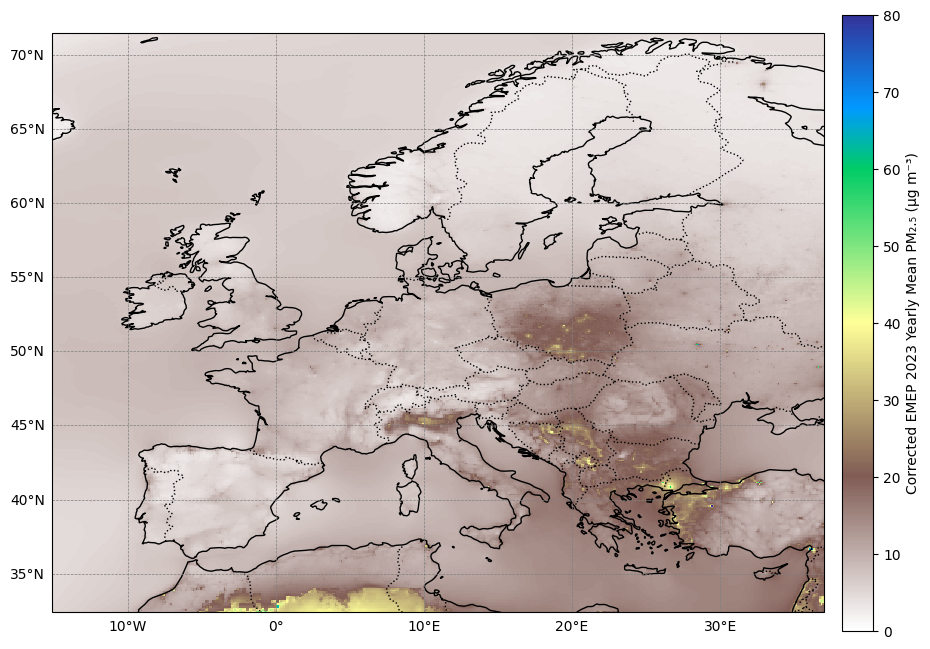

In [37]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2023_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2023 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

In [20]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
perturbed_scenario_nc_path = "EMEP_yearly_2024.nc"  # Perturbed scenario NetCDF
interpolated_residual_nc_path = "Bias_Hybrid_Optimized_PM25.nc"  # Interpolated residuals NetCDF
base_raw_nc_path = "EMEP_yearly_2015.nc"  # Raw modeled base NetCDF
corrected_scenario_nc_path = "Scenario_Corrected4_PM25_Y_ADI_ADD.nc"  # Output corrected scenario NetCDF

# === Load NetCDF Data ===
with nc.Dataset(perturbed_scenario_nc_path, "r") as pert_nc, \
     nc.Dataset(interpolated_residual_nc_path, "r") as res_nc, \
     nc.Dataset(base_raw_nc_path, "r") as base_nc:

    # Load variables
    lon = pert_nc.variables["lon"][:]
    lat = pert_nc.variables["lat"][:]
    time = pert_nc.variables["time"][:]
    scenario_perturb = pert_nc.variables["SURF_ug_PM25_rh50"][:]
    interpolated_residual = res_nc.variables["Interpolated_Bias"][:]
    base_raw = base_nc.variables["SURF_ug_PM25_rh50"][:]  # This is your BC

    # === Compute the Unbiased Scenario ===
    threshold = 1e-4
    ratio = np.where(base_raw > threshold, interpolated_residual / base_raw, 0.0)
    scenario_corrected = scenario_perturb * (1 + ratio)

    # === Save the Corrected Scenario to a New NetCDF File ===
    with nc.Dataset(corrected_scenario_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        scenario_var = new_nc.createVariable("SURF_ug_PM25_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original variable
        scenario_var.setncatts(pert_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        scenario_var[:] = scenario_corrected

print("Scenario Bias Correction Completed Successfully!")
print("Corrected PM₂.₅ Scenario NetCDF file saved as:", corrected_scenario_nc_path)

Scenario Bias Correction Completed Successfully!
Corrected PM₂.₅ Scenario NetCDF file saved as: Scenario_Corrected4_PM25_Y_ADI_ADD.nc


In [21]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "Scenario_Corrected4_PM25_Y_ADI_ADD.nc"  # Your original file
output_file = "Scen_2024_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2024.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: Scen_2024_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh5 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versi

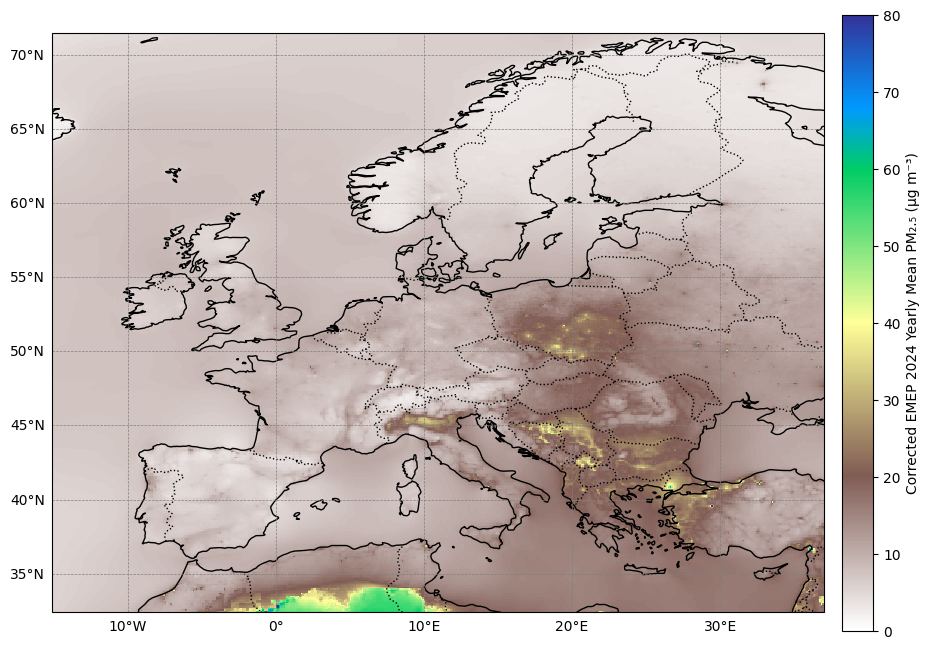

In [22]:


import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "Scen_2024_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2024 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 5.258649539145988
MAE: 3.4413187849404934
Bias: -1.0608119106907434
R: 0.6669691567549353
R² (corr): 0.44484785606238947
R² (true): 0.3843458981471186

ADI
RMSE: 1.0534658740196847
MAE: 0.6543077861535607
Bias: 0.03946642283419978
R: 0.9878193574115107
R² (corr): 0.97578708287689
R² (true): 0.9752924738399428

===== COUNTRY METRICS =====


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


   Country   RMSE_Raw  RMSE_WDI   Bias_Raw  Bias_WDI    R2_Raw    R2_WDI    N
18      LU   2.235698  0.106627   2.190796 -0.024790  0.512935  0.951523    3
28      XK  11.856372  0.152815 -11.856372 -0.152815       NaN       NaN    1
9       EE   1.434549  0.298810  -0.906214  0.119082  0.481903  0.986021    6
2       BE   3.923190  0.399435   3.283532  0.076152  0.580263  0.972721   38
24      RO   4.610950  0.432552  -3.475032  0.222146  0.772700  0.999757    3
15      IE   0.489383  0.435683   0.084941 -0.123761  0.856756  0.920372    6
21      NO   1.972644  0.551903  -1.224810  0.161670  0.604646  0.952228    9
1       AT   2.356627  0.582211   0.134136  0.015997  0.264843  0.947267   26
25      SE   1.713158  0.613026  -0.465415  0.216214  0.569057  0.946320   13
20      NL   3.319256  0.626060   3.178465  0.391184  0.210159  0.671275   12
6       CZ   4.605773  0.631425  -2.235541  0.143817  0.364477  0.984832   25
7       DE   2.290495  0.632650   1.113937  0.253086  0.256662  

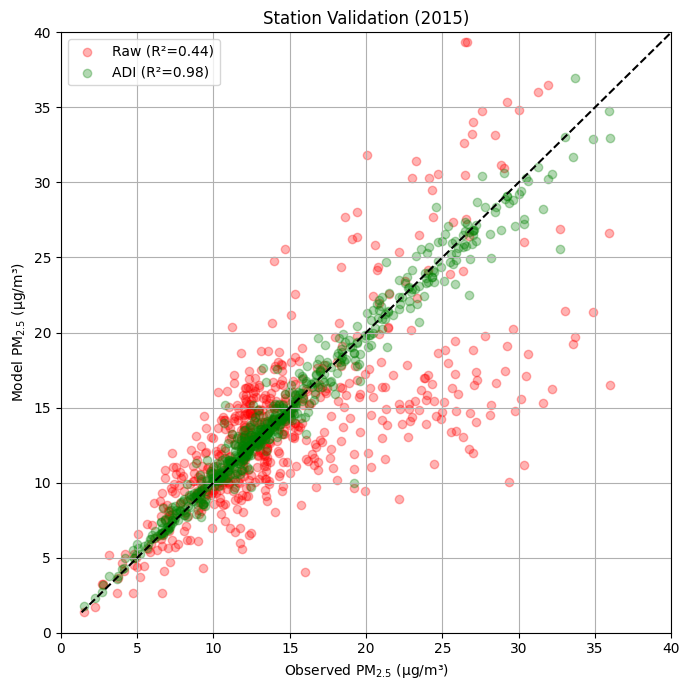

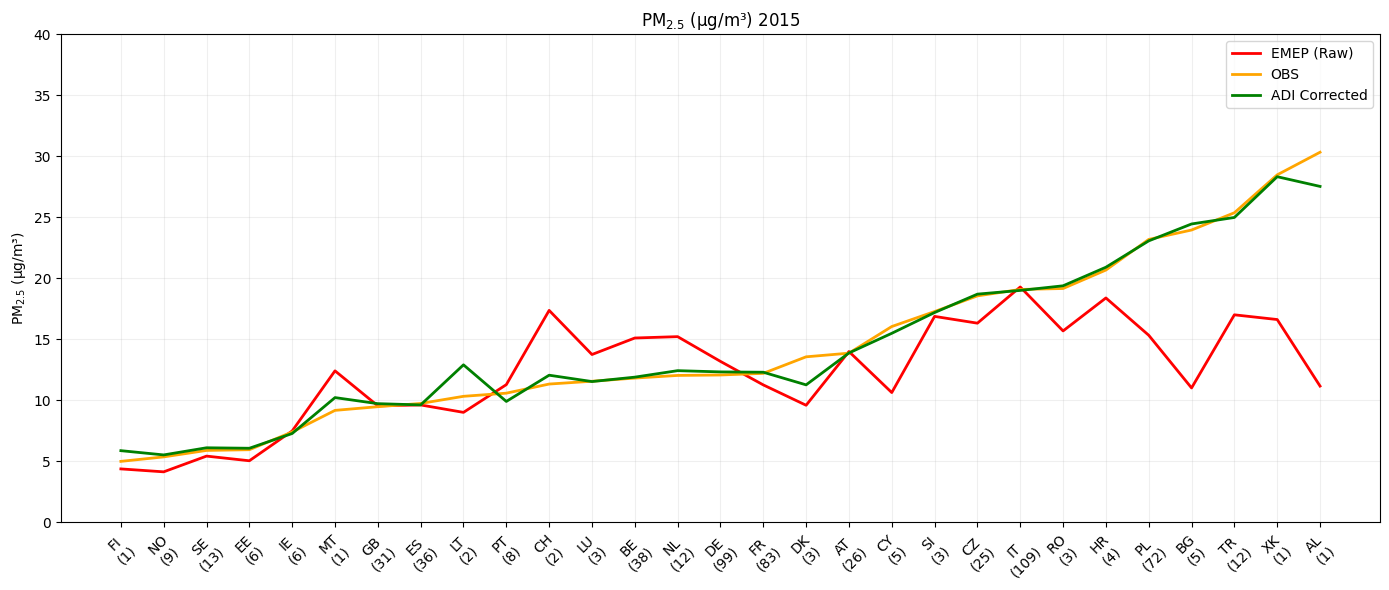

In [34]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2015.nc")
ds_wdi = xr.open_dataset("BaseCase_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2015.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2015)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2015")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.0742667208470857
MAE: 2.346514510738826
Bias: 1.254383751264528
R: 0.816002925020796
R² (corr): 0.6658607736424947
R² (true): 0.495439071202608

ADI
RMSE: 4.259667296685982
MAE: 2.7120196001401298
Bias: 2.4167959372398684
R: 0.852942325591113
R² (corr): 0.7275106107847763
R² (true): 0.03131652942678553


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)



===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
3       CH  3.446547   0.667418  3.366267  -0.537836  1.000000  1.000000   2
12      IE  1.080186   0.969642  0.518302   0.285875  0.594567  0.791344   4
20      SE  0.498301   1.148995  0.308085   0.896672  0.980168  0.985398   4
6       DE  2.121418   1.268258  1.404922   0.797410  0.273507  0.647688  86
1       BE  3.394064   1.581256  3.254225   0.955744  0.884049  0.792914  30
4       CY  2.895057   1.730984 -2.688960   1.346814  0.925766  0.874097   4
7       EE  0.973388   1.835900  0.574261   1.644546  0.086034  0.722611   6
15      NL  4.048195   1.954546  3.999193   1.665566  0.038777  0.005459  11
14      LU  3.711454   1.984959  3.651569   1.938861  0.028751  0.102754   3
0       AT  3.117559   2.116050  1.720850   1.565073  0.203897  0.652295  25
10      FR  1.315861   2.309553  0.446537   1.733728  0.490016  0.405874  53
9       FI  1.070855   2.698820  1.070855   2.6

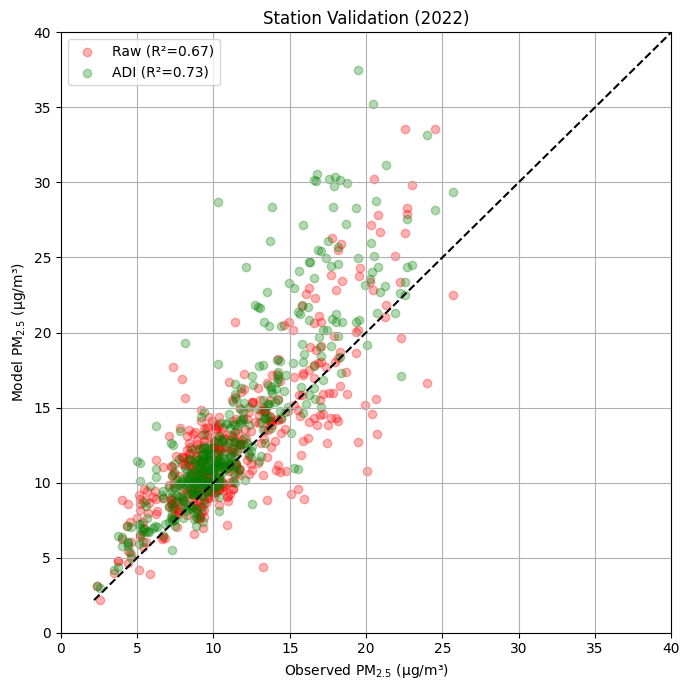

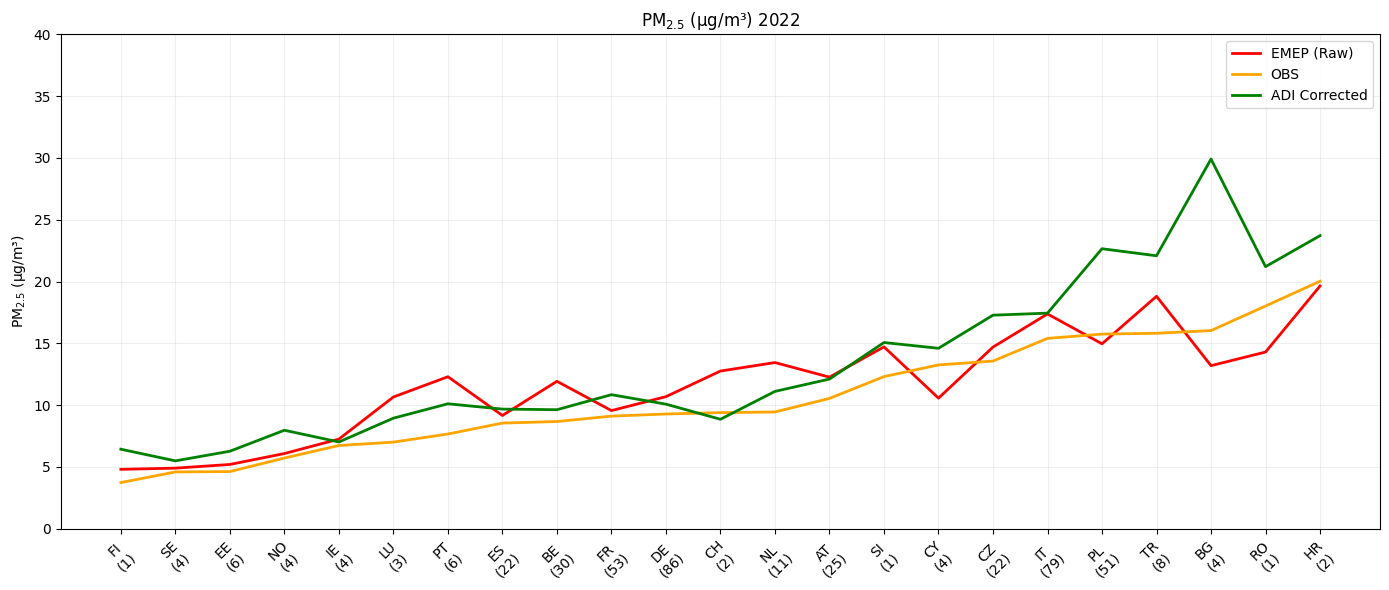

In [33]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2022.nc")
ds_wdi = xr.open_dataset("Scen_2022_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2022.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2022)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2022")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 2.9468605827027425
MAE: 2.165125097721015
Bias: 0.7773300713905382
R: 0.7813692660277803
R² (corr): 0.6105379298927922
R² (true): 0.4746326738613982

ADI
RMSE: 3.6005547337141692
MAE: 2.2757451482874678
Bias: 1.7547691830418068
R: 0.8381924368378088
R² (corr): 0.702566561172104
R² (true): 0.21569909783353003

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw  Bias_WDI    R2_Raw    R2_WDI   N
3       CH  3.086469   0.200205  3.076622 -0.198087  1.000000  1.000000   2
12      IE  0.476634   0.349539  0.280882  0.080961  0.710592  0.953207   4
6       DE  1.877030   1.030428  1.088131  0.557655  0.219194  0.631546  86
20      SE  0.505869   1.294250  0.459812  1.006449  0.995148  0.901749   4
0       AT  2.191249   1.385149  0.985831  0.883949  0.323033  0.754940  25
14      LU  2.848934   1.509676  2.819398  1.368601  0.999521  0.740277   3
7       EE  0.777466   1.646008  0.359796  1.380265  0.3

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


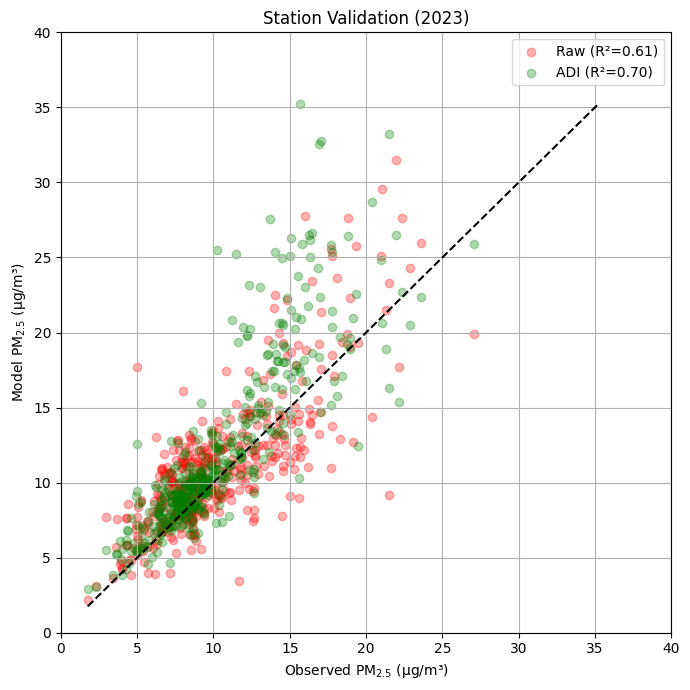

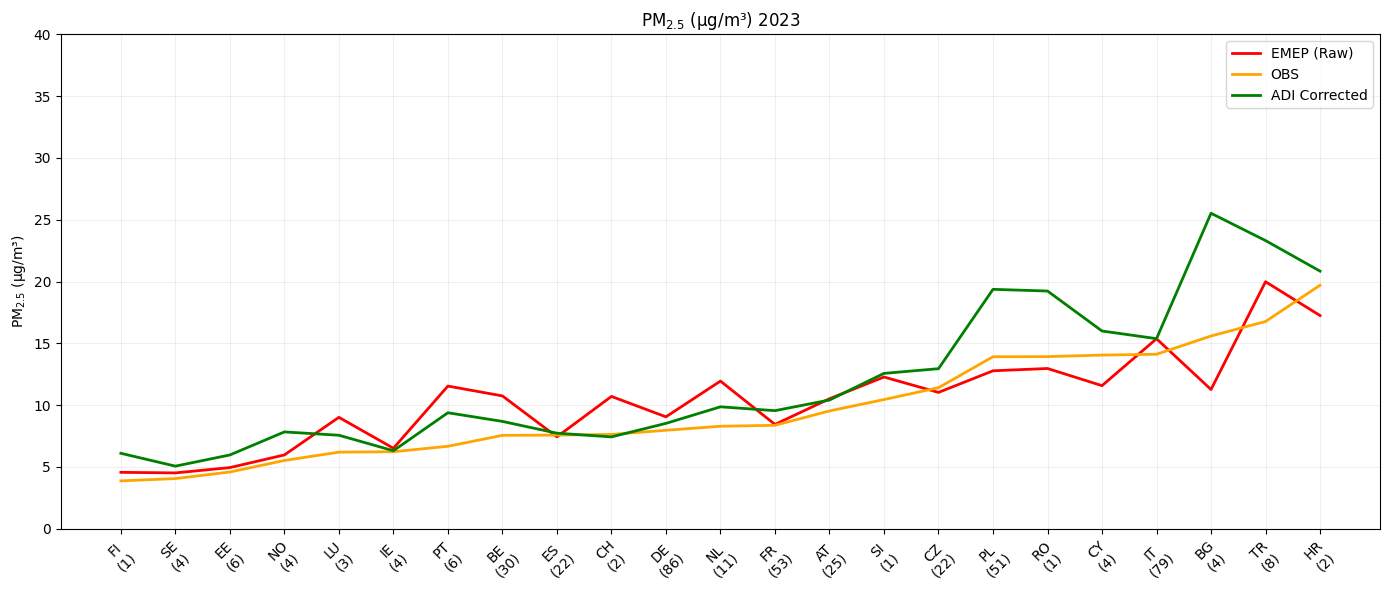

In [42]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2023.nc")
ds_wdi = xr.open_dataset("Scen_2023_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2023.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2023)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2023")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

Shapes: (391, 521) (391, 521)

===== GLOBAL PERFORMANCE =====

RAW
RMSE: 3.8510680947070632
MAE: 2.9033679138282866
Bias: 1.9934758279552327
R: 0.7663786253794099
R² (corr): 0.5873361974384339
R² (true): 0.12835636598149036

ADI
RMSE: 4.608856905583731
MAE: 3.242191114239825
Bias: 3.035989189032852
R: 0.8603742904979734
R² (corr): 0.7402439197498911
R² (true): -0.24842660667427108

===== COUNTRY METRICS =====
   Country  RMSE_Raw   RMSE_WDI  Bias_Raw   Bias_WDI    R2_Raw    R2_WDI   N
3       CH  4.541475   0.820759  4.522708   0.817169  1.000000  1.000000   2
12      IE  1.056765   0.833624  0.642099   0.427740  0.421718  0.795272   4
20      SE  0.771162   1.516681  0.648879   1.248666  0.990979  0.963822   4
14      LU  3.067564   1.873692  2.931710   1.499368  0.642928  0.124215   3
16      NO  2.833435   1.988505  0.480642   1.881886  0.219250  0.935911   4
6       DE  3.016868   2.026809  2.423615   1.814642  0.194634  0.692806  86
15      NL  4.293688   2.141720  4.188090   1.95

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2914: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2773: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


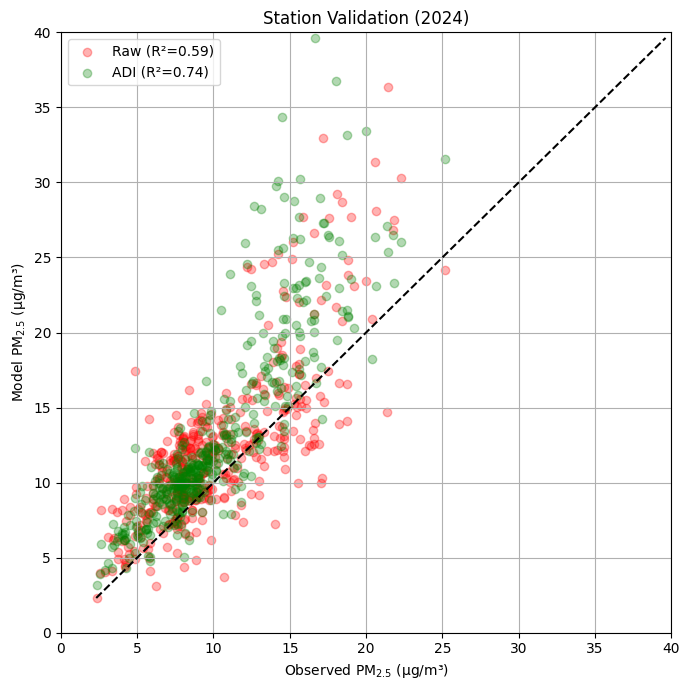

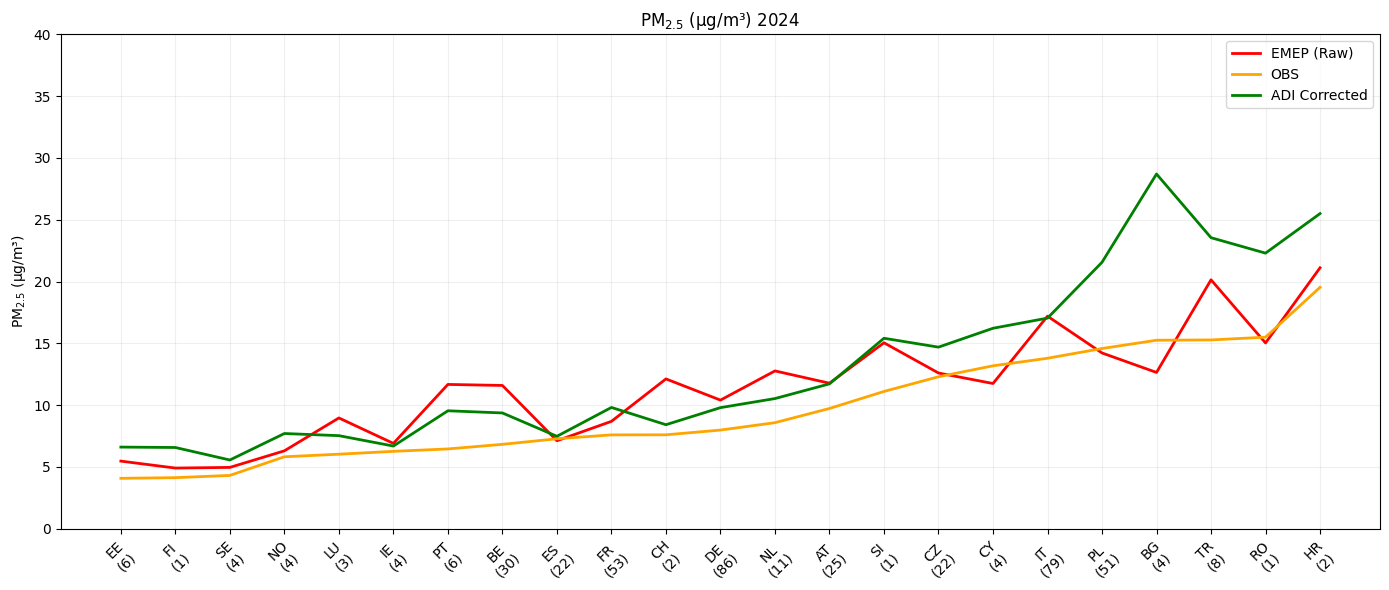

In [31]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# ======================================================
# 1. LOAD MODELS
# ======================================================
ds_raw = xr.open_dataset("EMEP_yearly_2024.nc")
ds_wdi = xr.open_dataset("Scen_2024_NKUA_PM25_CSA.Cell.Add.ADI_CORR_YEARLY.nc")

lon = ds_raw["lon"].values
lat = ds_raw["lat"].values

raw = ds_raw["SURF_ug_PM25_rh50"].values
wdi = ds_wdi["SURF_ug_PM25_rh50"].values

# handle time dimension
if raw.ndim == 3:
    raw = raw[0]
if wdi.ndim == 3:
    wdi = wdi[0]

ds_raw.close()
ds_wdi.close()

print("Shapes:", raw.shape, wdi.shape)

# ======================================================
# 2. LOAD STATIONS
# ======================================================
df = pd.read_csv("yearly_PM25_2024.csv")

if df["Longitude"].max() > 180:
    df["Longitude"] = ((df["Longitude"] + 180) % 360) - 180

df["Country"] = df["Station"].str[:2]

# ======================================================
# 3. BILINEAR INTERPOLATION
# ======================================================
def bilinear_interp(lon_pt, lat_pt, lon, lat, field):

    i = np.searchsorted(lon, lon_pt) - 1
    j = np.searchsorted(lat, lat_pt) - 1

    i = np.clip(i, 0, len(lon) - 2)
    j = np.clip(j, 0, len(lat) - 2)

    x1, x2 = lon[i], lon[i+1]
    y1, y2 = lat[j], lat[j+1]

    Q11 = field[j, i]
    Q21 = field[j, i+1]
    Q12 = field[j+1, i]
    Q22 = field[j+1, i+1]

    return (
        Q11 * (x2 - lon_pt) * (y2 - lat_pt) +
        Q21 * (lon_pt - x1) * (y2 - lat_pt) +
        Q12 * (x2 - lon_pt) * (lat_pt - y1) +
        Q22 * (lon_pt - x1) * (lat_pt - y1)
    ) / ((x2 - x1) * (y2 - y1))

# ======================================================
# 4. EXTRACT MODEL VALUES
# ======================================================
raw_vals = []
wdi_vals = []

for _, row in df.iterrows():
    lo = row["Longitude"]
    la = row["Latitude"]

    raw_vals.append(bilinear_interp(lo, la, lon, lat, raw))
    wdi_vals.append(bilinear_interp(lo, la, lon, lat, wdi))

df["Model_Raw"] = raw_vals
df["Model_WDI"] = wdi_vals

# ======================================================
# 5. CLEAN
# ======================================================
df = df.dropna(subset=["Average", "Model_Raw", "Model_WDI"])

obs = df["Average"].values
raw_vals = df["Model_Raw"].values
wdi_vals = df["Model_WDI"].values

# ======================================================
# 6. METRICS
# ======================================================
def rmse(a, b):
    return np.sqrt(np.mean((a - b)**2))

def mae(a, b):
    return np.mean(np.abs(a - b))

def bias(a, b):
    return np.mean(a - b)

def corr(a, b):
    return np.corrcoef(a, b)[0,1]

def r2_from_corr(r):
    return r**2

def r2_true(model, obs):
    ss_res = np.sum((obs - model)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot

print("\n===== GLOBAL PERFORMANCE =====")

# compute once
r_raw = corr(raw_vals, obs)
r_wdi = corr(wdi_vals, obs)

r2_raw_corr = r2_from_corr(r_raw)
r2_wdi_corr = r2_from_corr(r_wdi)

r2_raw_true = r2_true(raw_vals, obs)
r2_wdi_true = r2_true(wdi_vals, obs)

print("\nRAW")
print("RMSE:", rmse(raw_vals, obs))
print("MAE:", mae(raw_vals, obs))
print("Bias:", bias(raw_vals, obs))
print("R:", r_raw)
print("R² (corr):", r2_raw_corr)
print("R² (true):", r2_raw_true)

print("\nADI")
print("RMSE:", rmse(wdi_vals, obs))
print("MAE:", mae(wdi_vals, obs))
print("Bias:", bias(wdi_vals, obs))
print("R:", r_wdi)
print("R² (corr):", r2_wdi_corr)
print("R² (true):", r2_wdi_true)

# ======================================================
# 7. COUNTRY METRICS
# ======================================================
results = []

for country, group in df.groupby("Country"):

    obs_c = group["Average"].values
    raw_c = group["Model_Raw"].values
    wdi_c = group["Model_WDI"].values

    r_raw_c = corr(raw_c, obs_c)
    r_wdi_c = corr(wdi_c, obs_c)

    results.append({
        "Country": country,
        "RMSE_Raw": rmse(raw_c, obs_c),
        "RMSE_WDI": rmse(wdi_c, obs_c),
        "Bias_Raw": bias(raw_c, obs_c),
        "Bias_WDI": bias(wdi_c, obs_c),
        "R2_Raw": r_raw_c**2,
        "R2_WDI": r_wdi_c**2,
        "N": len(group)
    })

metrics_df = pd.DataFrame(results).sort_values("RMSE_WDI")

print("\n===== COUNTRY METRICS =====")
print(metrics_df)

# ======================================================
# 8. SCATTER PLOT
# ======================================================
plt.figure(figsize=(7,7))

plt.scatter(obs, raw_vals,
            label=f"Raw (R²={r2_raw_corr:.2f})",
            alpha=0.3, color='red')

plt.scatter(obs, wdi_vals,
            label=f"ADI (R²={r2_wdi_corr:.2f})",
            alpha=0.3, color='green')

min_v = min(obs.min(), raw_vals.min(), wdi_vals.min())
max_v = max(obs.max(), raw_vals.max(), wdi_vals.max())

plt.plot([min_v, max_v], [min_v, max_v], 'k--')

plt.xlabel("Observed PM$_{2.5}$ (µg/m³)")
plt.ylabel("Model PM$_{2.5}$ (µg/m³)")
plt.title("Station Validation (2024)")
plt.xlim(0,40)
plt.ylim(0,40)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# ======================================================
# 9. COUNTRY PLOT
# ======================================================
country_mean = df.groupby("Country")[[
    "Average",
    "Model_Raw",
    "Model_WDI"
]].mean()

country_mean = country_mean.rename(columns={
    "Average": "OBS",
    "Model_Raw": "RAW",
    "Model_WDI": "WDI"
})

country_mean = country_mean.sort_values("OBS")

nstations = df.groupby("Country").size()
labels = [f"{c}\n({nstations[c]})" for c in country_mean.index]
x = np.arange(len(country_mean))

plt.figure(figsize=(14,6))

plt.plot(x, country_mean["RAW"], color='red', linewidth=2, label="EMEP (Raw)")
plt.plot(x, country_mean["OBS"], color='orange', linewidth=2, label="OBS")
plt.plot(x, country_mean["WDI"], color='green', linewidth=2, label="ADI Corrected")

plt.xticks(x, labels, rotation=45)
plt.ylabel("PM$_{2.5}$ (µg/m³)")
plt.title("PM$_{2.5}$ (µg/m³) 2024")
plt.ylim(0,40)
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()